<a href="https://colab.research.google.com/github/mnuvunm/2026_tues_bigdatacomputing_class/blob/main/class_tues_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ 데이터 과학 파이프라인의 전 과정
- Numpy : 다차원 배열 생성, 결합(concatenate(), vstack(),hstack(), column_stack()), 셔플링, 필터링(인덱싱/슬라이싱)

- Pandas : 데이터 구조화, 타입 변환, 그룹 분석(groupby(), pivot_table(), concat(), merge()), 데이터 추출(인덱싱, 슬라이싱), 결측치 보간(fillna(), isna(), dropna())

- 시각화 : matplotlib, seaborn, Pandas의 시각화 기능, DataFrame의 시각화 기능

- 데이터 분석 흐름: 데이터 생성(Numpy) → 데이터 구조화(Pandas) → 정제(Pre-processing) → 탐색적 데이터 분석(EDA) : 시각화 순서로 진행

- NumPy 기반의 시뮬레이션 코드를 Pandas의 DataFrame 구조로 확장하면, 데이터에 이름을 붙이고(Indexing), 통계치를 한눈에 확인하며, 시각화 라이브러리와의 연동




## ✅ Pandas 기능
- Series

In [1]:
#-------------------------------
# Series : List
#-------------------------------
import pandas as pd
import numpy as np

# 인덱스 자동 생성, 컬럼명 0
s = pd.Series([1,2,3, np.nan, 5, 6])
s = pd.Series(np.random.randn(5))

# 인덱스 지정
s = pd.Series(np.random.randn(5), index = [1,2,3,4,5])

# 시리즈의 이름 지정
s = pd.Series(np.random.randint(60, 90, 5), name="score")

# 시리즈의 데이터타입확인
print("\n", type(s))

# 시리즈의 결측치 확인
s = pd.Series([1,2,3, np.nan, 5, 6])

# 시리즈 값 추출
print(s[0]) # 인덱싱
print(s[:3]) # 슬라이싱

# 시리즈의 인덱스 변경
#(1)
s = pd.Series([1,2,3, np.nan, 5, 6], index = [1,2,3,4,5,6])
print("\n",s)

#(2)
s = pd.Series([1,2,3, np.nan, 5, 6])
s.index =  [1,2,3,4,5,6]
print("\n",s)

# 시리즈의 값 수정
s = pd.Series([1,2,3, np.nan, 5, 6])
s[3] = 0  #결측치 처리 - 영으로 지정
print("\n",s)

# 시리즈의 새로운 값 추가
s = pd.Series([1,2,3, np.nan, 5, 6])
s[7] = 7
print("\n",s)



 <class 'pandas.core.series.Series'>
1.0
0    1.0
1    2.0
2    3.0
dtype: float64

 1    1.0
2    2.0
3    3.0
4    NaN
5    5.0
6    6.0
dtype: float64

 1    1.0
2    2.0
3    3.0
4    NaN
5    5.0
6    6.0
dtype: float64

 0    1.0
1    2.0
2    3.0
3    0.0
4    5.0
5    6.0
dtype: float64

 0    1.0
1    2.0
2    3.0
3    NaN
4    5.0
5    6.0
7    7.0
dtype: float64


In [ ]:
#---------------------------------------
# Series : dictionary
#----------------------------------------
import pandas as pd
import numpy as np

income = {'jan': 80000, 'feb': 90000, 'mar': 79000}
income_s = pd.Series(income, name = "salary")
print( income_s)
print("\n",income_s.index.to_list())
print("\n", income_s.values) # numpy 1-d array
income_s.index = ['1M', '2M', '3M']
print("\n",income_s)
# 시리즈에서 최대값을 찾기
#(1)
print("\n", income_s.max())
#(2)
max_index = np.argmax(income_s)
print("\n", max_index)
print("\n", income_s[max_index])



jan    80000
feb    90000
mar    79000
Name: salary, dtype: int64

 ['jan', 'feb', 'mar']

 [80000 90000 79000]

 1M    80000
2M    90000
3M    79000
Name: salary, dtype: int64

 90000

 1

 90000


/tmp/ipykernel_1458/4065113321.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("\n", income_s[max_index])


## ✅ Pandas 기능
- DataFrame
  - 필터링
  - 병합

In [ ]:
#-----------------------------------------------
# DataFrame : 복수 개의 시리즈을 딕셔너리로 이용
#------------------------------------------------
import pandas as pd
import numpy as np
# 데이터프레임 (표) 생성
month_s = pd.Series(['jan', 'feb', 'mar'])
income_s = pd.Series([9700, 6000, 9000])
expense_s = pd.Series([5040, 7000, 8900])

df = pd.DataFrame({'월':month_s, '수입':income_s, '지출':expense_s}, index = range(0,3))
print(df)
# 데이터프레임의 속성
print("\n",df.index.to_list())
print("\n",df.columns.to_list())
print("\n",df.values ) # numpy 2d-array


# 데이터프레임의 인덱스 재설정
df.index = ["M1", "M2","M3"]
print("\n", df)

# 데이터프레임의 특정 컬럼(열) 추출
# (1)인덱싱
print("\n",df['월']) # 시리즈 반환
print("\n", df[['월', '지출']]) # 일부 데이터프레임 반환

# 데이터프레임의 특정 행 추출
# print("\n",df['M1']) # error
print("\n", df.loc['M1']) # 첫번째 행 추출
print("\n", df.loc[["M1", "M3"]])

# 데이터프레임의 특정 데이터 추출 (행, 열)
print("\n", df.loc['M1', '수입'])

# 데이터프레임에 새로운 컬럼 추가
df['잔액'] = df['수입'] - df['지출'] # 넘파이의 벡터화 연산
print("\n", df)
print("\n",df.head(2))
print("\n", df.tail(2))

# 논리 인덱싱 조건을 이용해서 새로운 컬럼 추가
df['적자'] = np.where(df['잔액'] < 0, "minus", "ok")
print("\n", df)

# 논리인덱싱을 이용하여 특정 조건을 만족하는 데이터프레임 필터링
print("\n", df[df['잔액'] > 0])


     월    수입    지출
0  jan  9700  5040
1  feb  6000  7000
2  mar  9000  8900

 [0, 1, 2]

 ['월', '수입', '지출']

 [['jan' 9700 5040]
 ['feb' 6000 7000]
 ['mar' 9000 8900]]

       월    수입    지출
M1  jan  9700  5040
M2  feb  6000  7000
M3  mar  9000  8900

 M1    jan
M2    feb
M3    mar
Name: 월, dtype: object

       월    지출
M1  jan  5040
M2  feb  7000
M3  mar  8900

 월      jan
수입    9700
지출    5040
Name: M1, dtype: object

       월    수입    지출
M1  jan  9700  5040
M3  mar  9000  8900

 9700

       월    수입    지출    잔액
M1  jan  9700  5040  4660
M2  feb  6000  7000 -1000
M3  mar  9000  8900   100

       월    수입    지출    잔액
M1  jan  9700  5040  4660
M2  feb  6000  7000 -1000

       월    수입    지출    잔액
M2  feb  6000  7000 -1000
M3  mar  9000  8900   100

       월    수입    지출    잔액     적자
M1  jan  9700  5040  4660     ok
M2  feb  6000  7000 -1000  minus
M3  mar  9000  8900   100     ok

       월    수입    지출    잔액  적자
M1  jan  9700  5040  4660  ok
M3  mar  9000  8900   100  ok


In [ ]:
#----------------------------
# DataFrame 합치기 : pd.concat()
#-------------------------------
df1 = pd.DataFrame({'A': ['A0', 'A1'], 'B': ['B0', 'B1']})
df2 = pd.DataFrame({'A': ['A2', 'A3'], 'B': ['B2', 'B3']})
df3 = pd.DataFrame({'C': ['A2', 'A3']}) # NaN
df4 = pd.DataFrame({'D': ['A2']})

print(df1)
print("\n",df1.shape)
print("\n",df2)
print("\n",df3)
print("\n",df4)

# 위-아래로 합치기
result_v = pd.concat([df1, df2], axis = 0, join='outer') # outer -> 컬럼 레이블에 대한 합집합
print("\n", result_v)

result_v = pd.concat([df1, df2, df3], axis = 0)
print("\n", result_v)

    A   B
0  A0  B0
1  A1  B1

 (2, 2)

     A   B
0  A2  B2
1  A3  B3

     C
0  A2
1  A3

     D
0  A2

     A   B
0  A0  B0
1  A1  B1
0  A2  B2
1  A3  B3

      A    B    C
0   A0   B0  NaN
1   A1   B1  NaN
0   A2   B2  NaN
1   A3   B3  NaN
0  NaN  NaN   A2
1  NaN  NaN   A3


In [25]:
import pandas as pd

#---------------------------------------
# 두 개의 1월과 2월의 매출 표 생성
#---------------------------------------
jan = pd.DataFrame({'매출':[100, 200]}, index = ['A상품', 'B상품'])
feb = pd.DataFrame({'매출':[150, 300], '할인율':[0.1, 0.2]}, index = ['A상품', 'C상품'])

print(jan)
print("\n", feb)

#---------------------------------------
# 1. 1월과 2월을 통합하기
#---------------------------------------
total_outer = pd.concat([jan, feb], axis = 0, join = 'outer')
print("\n", total_outer)

#---------------------------------------
# 2. 월별 매출 정보만 통합하기
#---------------------------------------
total_inner = pd.concat([jan, feb], axis = 0, join = 'inner')
print("\n", total_inner)

#---------------------------------------
# 3. 1월과 2월 상품에 대한 내용 통합하기: axis = 1 {모든 컬럼이 다 나옴}
#---------------------------------------
total_outer = pd.concat([jan, feb], axis = 1, join = 'outer', keys = ['jan', 'feb'])
print("\n", total_outer)

#---------------------------------------
# 4. 공통 상품에 대한 내용 통합하기: axis = 1 {모든 컬럼이 다 나옴}
#---------------------------------------
total_inner = pd.concat([jan, feb], axis = 1, join = 'inner', keys = ['jan', 'feb'])
print("\n", total_inner)


      매출
A상품  100
B상품  200

       매출  할인율
A상품  150  0.1
C상품  300  0.2

       매출  할인율
A상품  100  NaN
B상품  200  NaN
A상품  150  0.1
C상품  300  0.2

       매출
A상품  100
B상품  200
A상품  150
C상품  300

        jan    feb     
        매출     매출  할인율
A상품  100.0  150.0  0.1
B상품  200.0    NaN  NaN
C상품    NaN  300.0  0.2

      jan  feb     
      매출   매출  할인율
A상품  100  150  0.1


#### 응용문제: 데이터 통합 및 관측치 제어 및 seaborn 시각화

## ✅ Pandas 기능
- pd.concat()


✅ 환경 설정 및 한글 폰트 로드 완료

     기온
5월  20
6월  22
7월  25

       기온   풍속
5월  21.0  3.2
6월   NaN  4.1
8월  25.0  3.8

결합 직후
             기온   풍속
2021년 5월  20.0  NaN
      6월  22.0  NaN
      7월  25.0  NaN
2022년 5월  21.0  3.2
      6월   NaN  4.1
      8월  25.0  3.8

             기온   풍속
2021년 5월  20.0  0.0
      6월  22.0  0.0
      7월  25.0  0.0
2022년 5월  21.0  3.2
      6월  22.6  4.1
      8월  25.0  3.8


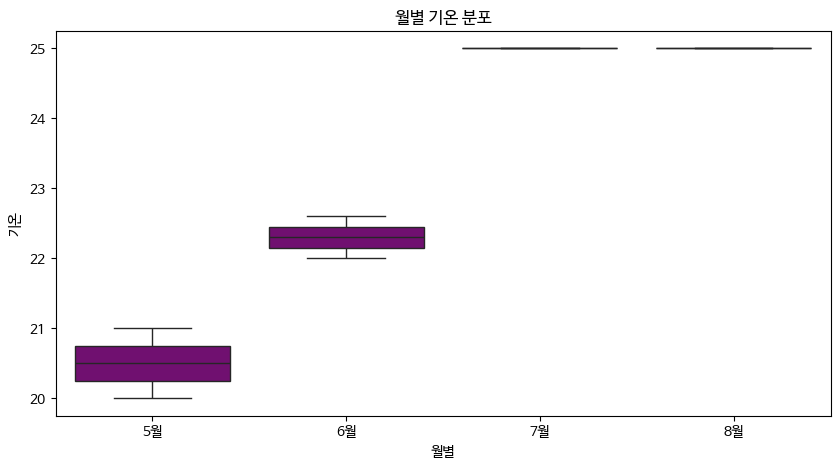

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

#----------------------------------------------
# [단계 2] 샘플 데이터 생성 (현업 상황 시뮬레이션)
#----------------------------------------------
df_2021 = pd.DataFrame({'기온': [20, 22, 25]}, index = ['5월', '6월', '7월'])
df_2022 = pd.DataFrame({'기온': [21, np.nan, 25], '풍속' : [3.2, 4.1, 3.8]}, index = ['5월', '6월', '8월'])
print("\n", df_2021)
print("\n", df_2022)

#----------------------------------------------
# [단계 3] 모든 월과 컬럼을 유지하며 물리적으로 결합 (axis = 0, join = 'outer)
#----------------------------------------------
combined = pd.concat([df_2021, df_2022], axis = 0, join = 'outer', keys = ['2021년', '2022년'])
print("\n결합 직후\n", combined)
#print("\n", combined.index)
#print("\n", combined.index.get_level_values(0))
#print("\n", combined.index.get_level_values(1))

#----------------------------------------------
# [단계 4] df.fillna()를 활용한 전략적 결측치 처리
#----------------------------------------------
clean_df = combined.fillna({
    '기온': combined['기온'].mean(), # 기온은 평균값으로
    '풍속': 0.0 # 풍속 데이터가 없으면 무풍(0) 처리
})
print("\n", clean_df)

#----------------------------------------------
# [단계 5] 시각화 [Seaborn Boxplot으로 분포 확인]: 데이터프레임의 시각화는 seaborn 라이브러리 이용
#----------------------------------------------
plt.figure(figsize = (10, 5))
sns.boxplot(data = clean_df, x = clean_df.index.get_level_values(1), y = "기온", color = 'purple')
plt.xlabel("월별")
plt.title("월별 기온 분포")
plt.show()


## ✅ Pandas 기능
- pd.merge

In [51]:
import pandas as pd

#--------------------------------------------
# DataFrame 병합: 공유하는 특정 키, 열을 기준으로 테이블을 결합: merge()
#--------------------------------------------
df_customers = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['김', '이', '박']}, index = ['가', '나', '다']) # 고객 정보
print(df_customers)

df_purchase_items = pd.DataFrame({'ID': [2, 3, 4, 5], 'Product': ['스마트폰', '노트북', '태블릿', '컴퓨터']}, index = ['다', '라', '마', '바'])
print("\n", df_purchase_items)

#--------------------------------------------
# 1. ID 번호가 같은 사람끼리 정보 행을 합치기: on = 'ID', how = 'inner'
#--------------------------------------------
# 행번호는 자동으로 ID의 공통개수(교집합)만큼 생성, 컬럼명은 모두 나옴
inner_res = pd.merge(df_customers, df_purchase_items, on = 'ID', how = 'inner')
print("\n", inner_res)

#--------------------------------------------
# 2. ID를 기준으로 구매한 모든 정보 합치기: on = 'ID', how = 'outer'
#--------------------------------------------
# 행번호는 자동으로 ID의 공통개수(합집합)만큼 생성, 컬럼명은 모두 나옴
outer_res = pd.merge(df_customers, df_purchase_items, on = 'ID', how = 'outer')
print("\n", outer_res)

#--------------------------------------------
# 3. 왼쪽 테이블 '기준이 되는 마스터 명부'에 정보를 덧붙이기: on = 'ID', Left join (왼쪽 기준) - how = 'left'
#--------------------------------------------
# 행번호는 자동으로 왼쪽 테이블의 ID의 전체 개수만큼 생성, 컬럼명은 모두 나옴
# 오른쪽 데이터프레임에는 없는 ID라면 해당 열은 NaN
left_res = df_customers.merge(df_purchase_items, on = 'ID', how = 'left')
print("\n", left_res)

#--------------------------------------------
# 4. 오른쪽 테이블 '주문 기록'을 기준으로 정보를 덧붙이기: on = 'ID', Right join (오른쪽 기준) - how = 'right'
#--------------------------------------------
right_res = df_customers.merge(df_purchase_items, on = 'ID', how = 'right')
print("\n", right_res)


   ID Name
가   1    김
나   2    이
다   3    박

    ID Product
다   2    스마트폰
라   3     노트북
마   4     태블릿
바   5     컴퓨터

    ID Name Product
0   2    이    스마트폰
1   3    박     노트북

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  NaN     태블릿
4   5  NaN     컴퓨터

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북

    ID Name Product
0   2    이    스마트폰
1   3    박     노트북
2   4  NaN     태블릿
3   5  NaN     컴퓨터


## ✅ Pandas 기능
- pd.pivot_table()
- pd.pivot()

In [65]:
import pandas as pd

# 1. 데이터 생성
df_A = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['김', '이', '박']}, index = ['가', '나', '다']) # 고객 정보
df_B = pd.DataFrame({'ID': [2, 3, 4, 5], 'Product': ['스마트폰', '노트북', '태블릿', '컴퓨터']})

# 2. 데이터 병합: 'ID'를 기준으로 모든 고객과 구매 정보를 유지하도록 병합 (merge)
merge_df = df_A.merge(df_B, on = 'ID', how = 'outer')
print("\n 데이터 병합 후 테이블\n", merge_df)

# 3. 데이터 가공 (피벗 전 처리)
# (1) Name 열에서 Name이 없는 경우(신규 고객) '비회원'으로 채우고, 업데이트 하기
merge_df['Name'] = merge_df['Name'].fillna('비회원')

# (2) 각 구매 수량을 1로 표시하는 '구매 수량' column 추가하기
merge_df['구매 수량'] = 1
print("\n", merge_df)

# 4. 피벗 테이블 생성
# 행(Index)은 고객 이름, 열(columns)은 상품명으로 설정하여 값(values)은 구매 수량을 집계
pivot_table = merge_df.pivot_table(index = 'Name', columns = 'Product', values = '구매 수량', aggfunc = 'sum')
pivot_res = pivot_table.fillna(0).astype(int)
print("\n", pivot_res)



 데이터 병합 후 테이블
    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  NaN     태블릿
4   5  NaN     컴퓨터

    ID Name Product  구매 수량
0   1    김     NaN      1
1   2    이    스마트폰      1
2   3    박     노트북      1
3   4  비회원     태블릿      1
4   5  비회원     컴퓨터      1

 Product  노트북  스마트폰  컴퓨터  태블릿
Name                        
박          1     0    0    0
비회원        0     0    1    1
이          0     1    0    0


## ✅ 시계열 날씨 데이터 (프로그래밍 과제)
- 웹상의 CSV 데이터를 읽어와 전처리(결측치 처리, 날짜 변환)를 수행하고,
- concat, merge, pivot_table 등 Pandas의 핵심 기능을 모두 포함한 통합 데이터 분석 파이프라인 코드를 작성.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

#-----------------------------------------------------------------
# 웹 데이터 로드
#-----------------------------------------------------------------
path = 'https://github.com/dongupak/DataML/raw/main/csv/'
weather = pd.read_csv(path + 'weather.csv', index_col=0, encoding='CP949')
# weather: DataFrame
print(weather.shape)
print(weather.head())
print(type(weather))
print(weather.columns)
print(weather.index) # index(['25-08-01], ...) -> Datetimeindex 변환


✅ 환경 설정 및 한글 폰트 로드 완료
(3653, 3)
            평균기온  최대풍속  평균풍속
일시                          
2010-08-01  28.7   8.3   3.4
2010-08-02  25.2   8.7   3.8
2010-08-03  22.1   6.3   2.9
2010-08-04  25.3   6.6   4.2
2010-08-05  27.2   9.1   5.6
<class 'pandas.core.frame.DataFrame'>
Index(['평균기온', '최대풍속', '평균풍속'], dtype='object')
Index(['2010-08-01', '2010-08-02', '2010-08-03', '2010-08-04', '2010-08-05',
       '2010-08-06', '2010-08-07', '2010-08-08', '2010-08-09', '2010-08-10',
       ...
       '2020-07-22', '2020-07-23', '2020-07-24', '2020-07-25', '2020-07-26',
       '2020-07-27', '2020-07-28', '2020-07-29', '2020-07-30', '2020-07-31'],
      dtype='object', name='일시', length=3653)
